# Import all models

## SARIMAX

In [2]:
from huggingface_hub import hf_hub_download
import joblib, pandas as pd, numpy as np
from sklearn.metrics import mean_squared_error

sarimax_model = joblib.load(hf_hub_download('kozy9/GWSarimax', 'sarimax_model.pkl'))
test_df = pd.read_csv('uk_test.csv')

features = ['temperature', 'precipitation', 'wind_speed']

sarimax_pred = sarimax_model.get_forecast(steps=len(test_df), exog=test_df[features]).predicted_mean

## LSTM

In [3]:
from huggingface_hub import hf_hub_download
from tensorflow.keras.models import load_model
import joblib, pandas as pd, numpy as np

# Load model and scalers
lstm_model    = load_model(hf_hub_download('kozy9/GWLSTM', 'lstm_model.keras'))
scaler_X = joblib.load(hf_hub_download('kozy9/GWLSTM', 'scaler_X.pkl'))
scaler_y = joblib.load(hf_hub_download('kozy9/GWLSTM', 'scaler_y.pkl'))

# Load your CSVs
train_df = pd.read_csv('uk_train.csv',    index_col='date', parse_dates=True)
val_df   = pd.read_csv('uk_validate.csv', index_col='date', parse_dates=True)
test_df  = pd.read_csv('uk_test.csv',     index_col='date', parse_dates=True)

FEATURES = ['water_level', 'temperature', 'precipitation', 'wind_speed']
LOOKBACK  = 24

# Scale using training-fitted scaler
train_arr = scaler_X.transform(train_df[FEATURES])
val_arr   = scaler_X.transform(val_df[FEATURES])
test_arr  = scaler_X.transform(test_df[FEATURES])

# Build test sequences with lookback buffer
test_input = np.vstack([val_arr[-LOOKBACK:], test_arr])

def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_test, y_test = create_sequences(test_input)

# Predict and inverse transform
ly_pred_scaled = lstm_model.predict(X_test)
ly_pred_inv    = scaler_y.inverse_transform(ly_pred_scaled).flatten()
ly_test_inv    = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()


lstm_model.keras:   0%|          | 0.00/676k [00:00<?, ?B/s]

scaler_X.pkl:   0%|          | 0.00/1.13k [00:00<?, ?B/s]

scaler_y.pkl:   0%|          | 0.00/975 [00:00<?, ?B/s]

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step 


## TCN

In [5]:
!pip install keras-tcn keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.6 MB/s eta 0:00:00


In [6]:
from huggingface_hub import hf_hub_download
from tensorflow.keras.models import load_model
import joblib, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tcn import TCN # Import TCN for custom object loading

# Load model and scalers
tcn_model           = load_model(hf_hub_download('kozy9/GWTCN', 'tcn_model.keras'))

scaler_features = joblib.load(hf_hub_download('kozy9/GWTCN', 'scaler_features.pkl'))
scaler_target   = joblib.load(hf_hub_download('kozy9/GWTCN', 'scaler_target.pkl'))

# Load CSVs
train_df = pd.read_csv('uk_train.csv',    index_col='date', parse_dates=True)
val_df   = pd.read_csv('uk_validate.csv', index_col='date', parse_dates=True)
test_df  = pd.read_csv('uk_test.csv',     index_col='date', parse_dates=True)

FEATURES = ['water_level', 'temperature', 'precipitation', 'wind_speed']
LOOKBACK  = 24

# Scale
train_arr = scaler_features.transform(train_df[FEATURES])
val_arr   = scaler_features.transform(val_df[FEATURES])
test_arr  = scaler_features.transform(test_df[FEATURES])

# Build test sequences with lookback buffer
test_input = np.vstack([val_arr[-LOOKBACK:], test_arr])

def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_test, y_test = create_sequences(test_input)

# Predict and inverse transform
ty_pred_scaled = tcn_model.predict(X_test)
ty_pred_inv    = scaler_target.inverse_transform(ty_pred_scaled).flatten()
ty_test_inv    = scaler_target.inverse_transform(y_test.reshape(-1,1)).flatten()

tcn_model.keras:   0%|          | 0.00/8.87M [00:00<?, ?B/s]

scaler_features.pkl:   0%|          | 0.00/1.13k [00:00<?, ?B/s]

scaler_target.pkl:   0%|          | 0.00/975 [00:00<?, ?B/s]

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


# Visualise all predictions

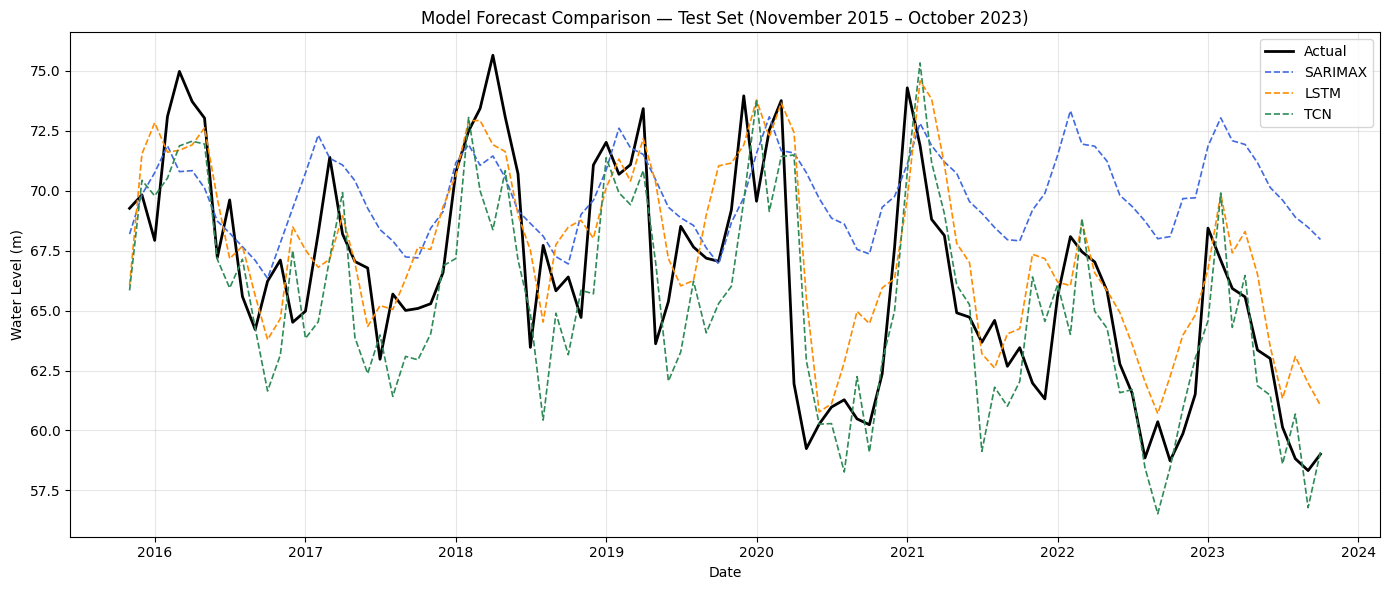

In [7]:
import matplotlib.pyplot as plt

# Test dates
test_dates = pd.read_csv('uk_test.csv', index_col='date', parse_dates=True).index

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates, ly_test_inv,  label='Actual',   color='black',      linewidth=2)
ax.plot(test_dates, sarimax_pred, label='SARIMAX',  color='royalblue',  linewidth=1.2, linestyle='--')
ax.plot(test_dates, ly_pred_inv,  label='LSTM',     color='darkorange',  linewidth=1.2, linestyle='--')
ax.plot(test_dates, ty_pred_inv,  label='TCN',      color='seagreen',   linewidth=1.2, linestyle='--')

ax.set_title('Model Forecast Comparison — Test Set (November 2015 – October 2023)')
ax.set_xlabel('Date')
ax.set_ylabel('Water Level (m)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

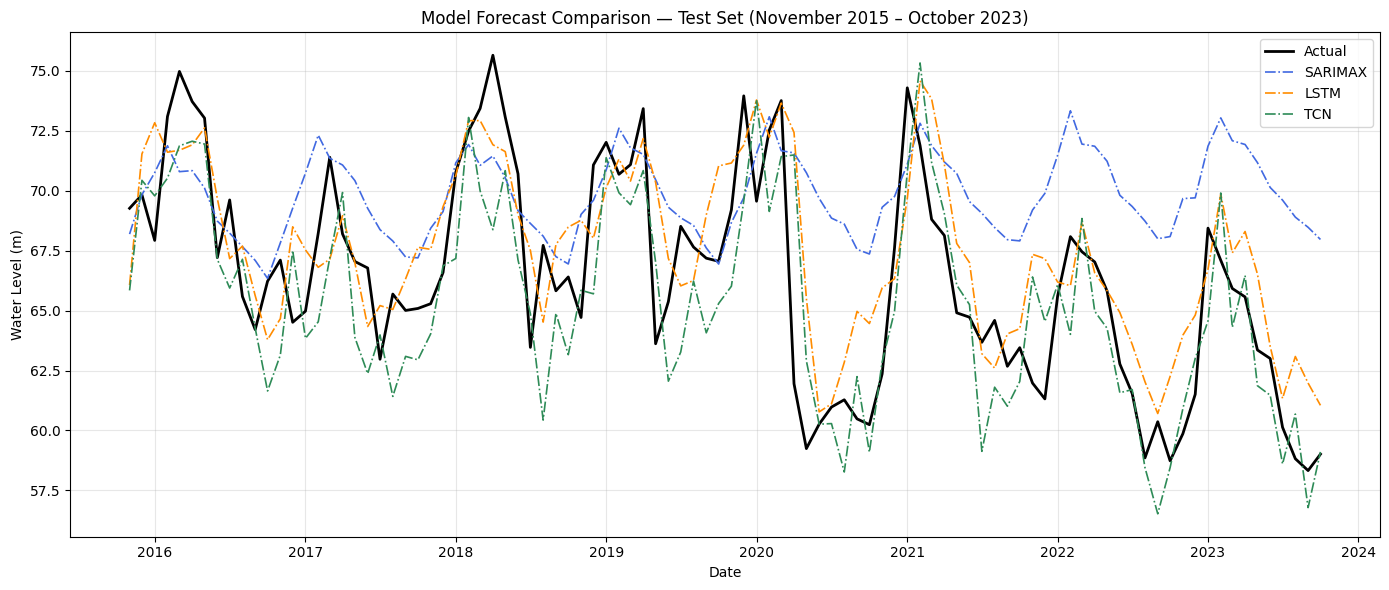

In [15]:
import matplotlib.pyplot as plt

# Test dates
test_dates = pd.read_csv('uk_test.csv', index_col='date', parse_dates=True).index

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates, ly_test_inv,  label='Actual',   color='black',      linewidth=2,linestyle='-')
ax.plot(test_dates, sarimax_pred, label='SARIMAX',  color='royalblue',  linewidth=1.2, linestyle='-.')
ax.plot(test_dates, ly_pred_inv,  label='LSTM',     color='darkorange',  linewidth=1.2, linestyle='-.')
ax.plot(test_dates, ty_pred_inv,  label='TCN',      color='seagreen',   linewidth=1.2, linestyle='-.')

ax.set_title('Model Forecast Comparison — Test Set (November 2015 – October 2023)')
ax.set_xlabel('Date')
ax.set_ylabel('Water Level (m)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

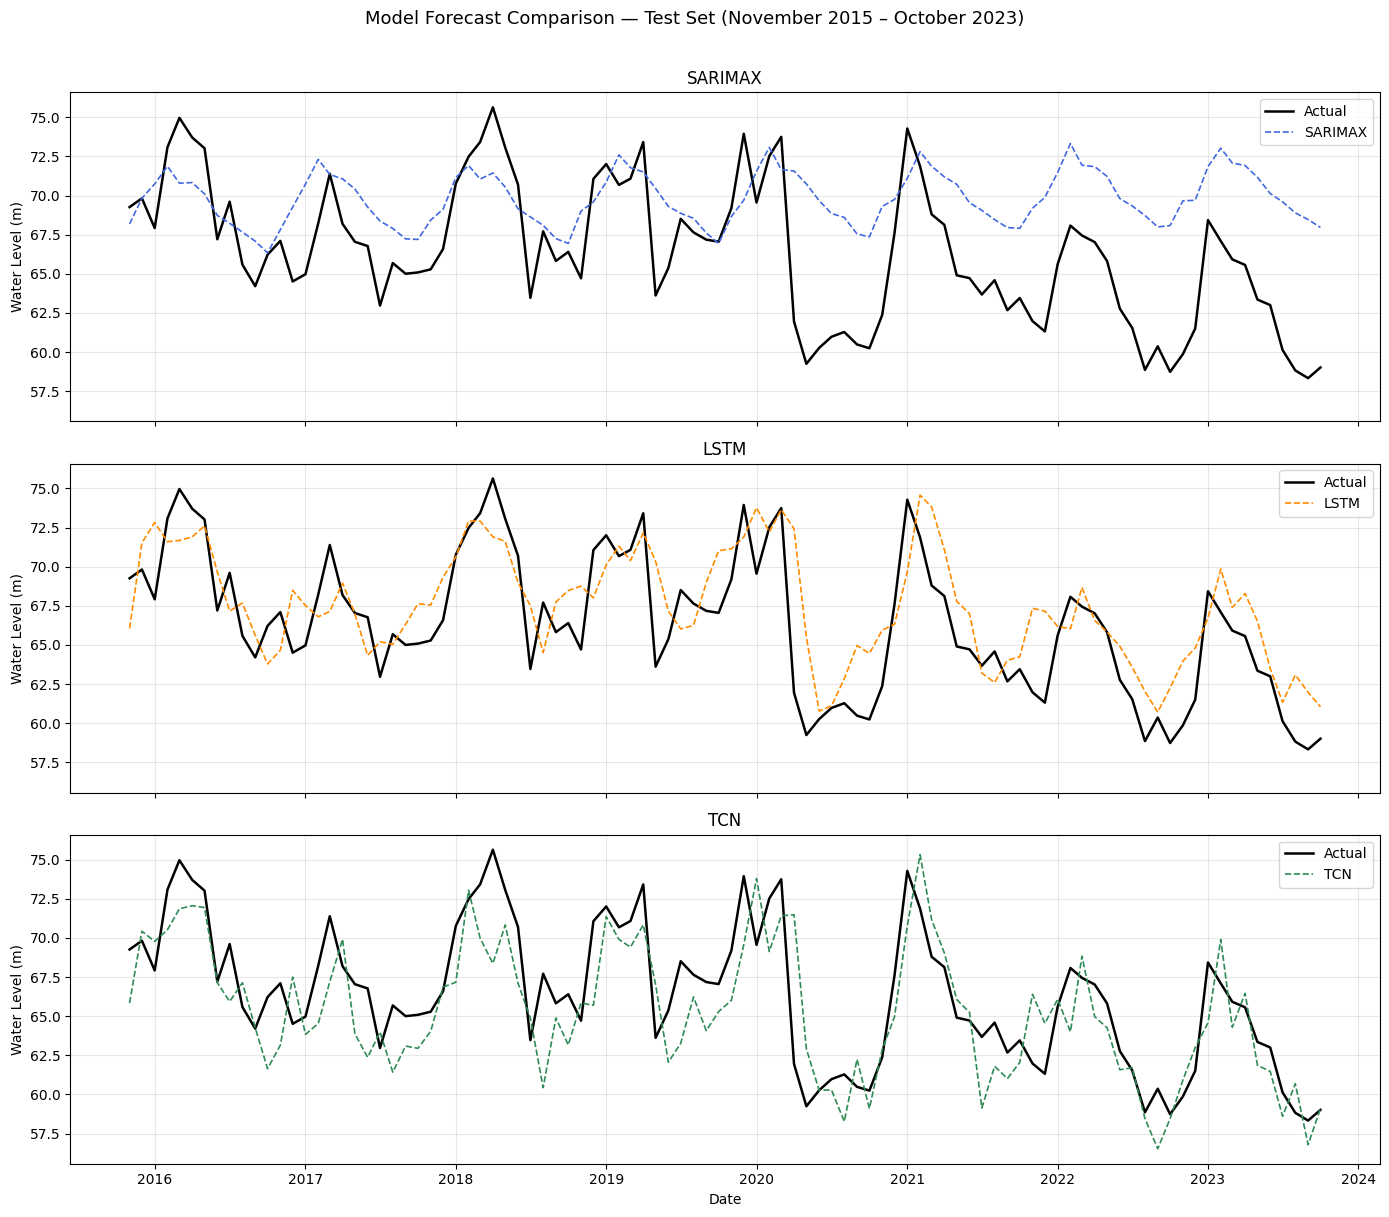

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True, sharey=True)

models = [
    (sarimax_pred, 'SARIMAX', 'royalblue'),
    (ly_pred_inv,  'LSTM',    'darkorange'),
    (ty_pred_inv,  'TCN',     'seagreen'),
]

for ax, (preds, name, colour) in zip(axes, models):
    ax.plot(test_dates, ly_test_inv, label='Actual', color='black', linewidth=1.8)
    ax.plot(test_dates, preds, label=name, color=colour, linewidth=1.2, linestyle='--')
    ax.set_ylabel('Water Level (m)')
    ax.set_title(name)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Model Forecast Comparison — Test Set (November 2015 – October 2023)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('model_comparison_subplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluation metrics comparsion

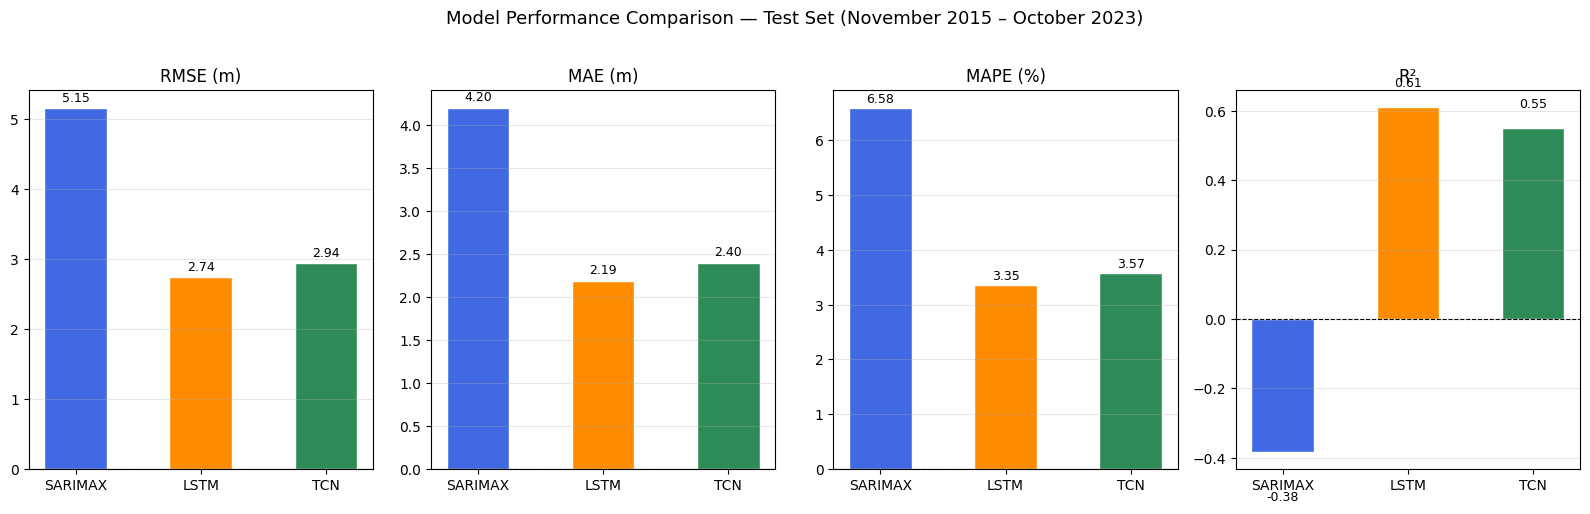

In [16]:
import matplotlib.pyplot as plt
import numpy as np

models  = ['SARIMAX', 'LSTM', 'TCN']
metrics = {
    'RMSE (m)': [5.154,   2.74,   2.9366],
    'MAE (m)' : [4.1969,  2.19,   2.3952],
    'MAPE (%)': [6.5844,  3.35,   3.5738],
    'R²'      : [-0.3826, 0.61,   0.5511],
    'NSE'     : [-0.3826, 0.61,   0.5511],
}

colours = ['royalblue', 'darkorange', 'seagreen']
x       = np.arange(len(models))
width   = 0.5

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric_name, values) in zip(axes, metrics.items()):
    if metric_name == 'NSE':   # skip NSE — same as R², already shown
        continue
    bars = ax.bar(x, values, width, color=colours, edgecolor='white')
    ax.set_title(metric_name, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.05 if val >= 0 else -0.15),
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Model Performance Comparison — Test Set (November 2015 – October 2023)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('model_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()